In [1]:
import sys
import subprocess
import sys
import subprocess
from enum import Enum  
import h5py
import numpy as np
from numpy.lib import recfunctions as rfn
import pandas as pd
import numpy as np
import torch
import polars as pl
import gc # Garbage collector
import math
import matplotlib.pyplot as plt
from numpy.lib import recfunctions as rfn
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
import torch.nn as nn
import torch.nn.functional as F
import torch.nn as nn
import torch.optim as optim
from torchinfo import summary
from torch.utils.data import TensorDataset, DataLoader
import torch
import matplotlib.pyplot as plt
import os
from sklearn.metrics import r2_score 
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from torch.optim.lr_scheduler import ReduceLROnPlateau
import matplotlib.colors as colors
import re
from sklearn.preprocessing import RobustScaler


result = subprocess.run(
    [sys.executable, "-m", "pip", "install", "h5py", "pandas", "numpy", "torch", "torch_optimizer", "polars", "matplotlib", "scikit-learn", "torchinfo"],
    stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

if result.returncode != 0:
    print("Installation failed.")

import importlib

def read_h5_data(file_name):
    with h5py.File(file_name, 'r') as file:
        particles = file['INPUTS']['PARTICLES'][:, :42]  # First 43 columns/features
        metadata = file['METADATA']['EVENT_DATA'][:]

        signal_inputs = rfn.structured_to_unstructured(particles)

        particles_keys = list(file['INPUTS']['PARTICLES'].dtype.names)[:42]
        input_keys_dict = {key: idx for idx, key in enumerate(particles_keys)}

    return signal_inputs, metadata, input_keys_dict

def load_multiple_h5(files):
    all_signals = []
    all_metadata = []
    input_keys_dict = None

    for f in files:
        signals, metadata, keys_dict = read_h5_data(f)

        print(f'File: {f} has {len(signals)} events')
        all_signals.append(signals)
        all_metadata.append(metadata)
        if input_keys_dict is None:
            input_keys_dict = keys_dict

    combined_signals = np.vstack(all_signals)
    combined_metadata = np.vstack(all_metadata)

    return combined_signals, combined_metadata, input_keys_dict

def flat_inputs(input_array, n_particles, feature_indices=None):
    if feature_indices is None:
        feature_indices = list(range(input_array.shape[2]))  # Use all features if none specified

    # Select specific particles and features
    output_array = input_array[:, :n_particles, feature_indices]
    
    # Transpose to (samples, features, particles)
    output_array = output_array.transpose(0, 2, 1)
    
    # Flatten to (samples, n_particles * n_features_selected)
    return output_array.reshape(-1, n_particles * len(feature_indices))
    
class MetadataIndex(Enum):
    # EVENT_NUMBER = 0 No need to assing this a n
    OMEGA = 1
    MZ_RECO = 2
    MZ_TRUTH = 3
    MMC_MZ = 4
    OPENING_ANGLE = 5
    LEP_MET_ANGLE_SIGNED = 6
    IS_MET_INSIDE = 7
    IS_EVENT_TPG_HADEL = 8
    TAU_GOOD_ID = 9
    TAU_GOOD_N_TRACKS = 10
    TAU_NN_DECAY = 11

In [43]:
import glob

# Get all .h5 files in the H5Dumper directory
files = glob.glob('../../../H5Dumper/*.h5')

# Optional: sort the list if needed
files.sort()

# Call your function
signal_inputs, metadata_inputs, input_keys_dict = load_multiple_h5(files)

# Print file list
for f in files:
    print(f)


with h5py.File('../../../H5Dumper/VBF_Ztautau_PoPy_600939_mc20a_fullsim.h5', 'r') as file:
    columns = [name.decode() for name in file['METADATA']['EVENT_DATA'].attrs['columns']]
    print(columns)

File: ../../../H5Dumper/VBFHtautau_346190_mc20a_fullsim.h5 has 1069 events
File: ../../../H5Dumper/VBFHtautau_346190_mc20d_fullsim.h5 has 1634 events
File: ../../../H5Dumper/VBFHtautau_346190_mc20e_fullsim.h5 has 2282 events
File: ../../../H5Dumper/VBFHtautau_346191_mc20a_fullsim.h5 has 47304 events
File: ../../../H5Dumper/VBFHtautau_346191_mc20d_fullsim.h5 has 58323 events
File: ../../../H5Dumper/VBFHtautau_346191_mc20e_fullsim.h5 has 80528 events
File: ../../../H5Dumper/VBFHtautau_346192_mc20a_fullsim.h5 has 47206 events
File: ../../../H5Dumper/VBFHtautau_346192_mc20d_fullsim.h5 has 57919 events
File: ../../../H5Dumper/VBFHtautau_346192_mc20e_fullsim.h5 has 80595 events
File: ../../../H5Dumper/VBFHtautau_346193_mc20a_fullsim.h5 has 526 events
File: ../../../H5Dumper/VBFHtautau_346193_mc20d_fullsim.h5 has 755 events
File: ../../../H5Dumper/VBFHtautau_346193_mc20e_fullsim.h5 has 1016 events
File: ../../../H5Dumper/VBF_Ztautau_PoPy_600939_mc20a_fullsim.h5 has 24532 events
File: ../../..

In [45]:
VBF_files = [
'../../../H5Dumper/VBF_Ztautau_PoPy_600939_mc20a_fullsim.h5',
'../../../H5Dumper/VBF_Ztautau_PoPy_600939_mc20d_fullsim.h5',
'../../../H5Dumper/VBF_Ztautau_PoPy_600939_mc20e_fullsim.h5',
'../../../H5Dumper/VBF_Ztautau_Sherpa2211_700360_mc20a_fullsim.h5',
'../../../H5Dumper/VBF_Ztautau_Sherpa2211_700360_mc20d_fullsim.h5',
'../../../H5Dumper/VBF_Ztautau_Sherpa2211_700360_mc20e_fullsim.h5',
]


Drell_Yan_files = [
'../../../H5Dumper/Ztautau_1_jets_2016_700792_mc20a_fullsim.h5',
'../../../H5Dumper/Ztautau_1_jets_2017_700792_mc20d_fullsim.h5',
'../../../H5Dumper/Ztautau_1_jets_2018_700792_mc20e_fullsim.h5',
'../../../H5Dumper/Ztautau_2_jets_2016_700793_mc20a_fullsim.h5',
'../../../H5Dumper/Ztautau_2_jets_2017_700793_mc20d_fullsim.h5',
'../../../H5Dumper/Ztautau_PoPy_361108_mc20a_fullsim.h5',
'../../../H5Dumper/Ztautau_PoPy_361108_mc20d_fullsim.h5',
'../../../H5Dumper/Ztautau_PoPy_361108_mc20e_fullsim.h5',
'../../../H5Dumper/Ztautau_2_jets_2018_700793_mc20e_fullsim.h5',
'../../../H5Dumper/Ztautau_3_jets_2016_700794_mc20a_fullsim.h5',
'../../../H5Dumper/Ztautau_3_jets_2017_700794_mc20d_fullsim.h5',
'../../../H5Dumper/Ztautau_3_jets_2018_700794_mc20e_fullsim.h5',
]

# =========== LOAD AND CALCALUTE RELEVANT DATA =========================#
# Load VBF
vbf_signal_inputs, vbf_metadata_inputs, input_keys_dict = load_multiple_h5(VBF_files)

# Remove bugged events (where MMC_MZ == 0)
vbf_valid = vbf_metadata_inputs[:, MetadataIndex.MMC_MZ.value] != 0
vbf_signal = vbf_signal_inputs[vbf_valid]
vbf_metadata = vbf_metadata_inputs[vbf_valid]

# Load Drell-Yan
dy_signal_inputs, dy_metadata_inputs, _ = load_multiple_h5(Drell_Yan_files)

# Remove bugged events (where MMC_MZ == 0)
dy_valid = dy_metadata_inputs[:, MetadataIndex.MMC_MZ.value] != 0
dy_signal = dy_signal_inputs[dy_valid]
dy_metadata = dy_metadata_inputs[dy_valid]

File: ../../../H5Dumper/VBF_Ztautau_PoPy_600939_mc20a_fullsim.h5 has 24532 events
File: ../../../H5Dumper/VBF_Ztautau_PoPy_600939_mc20d_fullsim.h5 has 30938 events
File: ../../../H5Dumper/VBF_Ztautau_PoPy_600939_mc20e_fullsim.h5 has 50388 events
File: ../../../H5Dumper/VBF_Ztautau_Sherpa2211_700360_mc20a_fullsim.h5 has 22976 events
File: ../../../H5Dumper/VBF_Ztautau_Sherpa2211_700360_mc20d_fullsim.h5 has 29306 events
File: ../../../H5Dumper/VBF_Ztautau_Sherpa2211_700360_mc20e_fullsim.h5 has 36298 events
File: ../../../H5Dumper/Ztautau_1_jets_2016_700792_mc20a_fullsim.h5 has 45965 events
File: ../../../H5Dumper/Ztautau_1_jets_2017_700792_mc20d_fullsim.h5 has 57263 events
File: ../../../H5Dumper/Ztautau_1_jets_2018_700792_mc20e_fullsim.h5 has 142136 events
File: ../../../H5Dumper/Ztautau_2_jets_2016_700793_mc20a_fullsim.h5 has 225106 events
File: ../../../H5Dumper/Ztautau_2_jets_2017_700793_mc20d_fullsim.h5 has 304317 events
File: ../../../H5Dumper/Ztautau_PoPy_361108_mc20a_fullsim.h5 h

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import os

def plot_dy_vs_vbf_distributions(vbf_data, dy_data, x_range=None, variable_name='', n_bins=40, title=''):
    plt.figure(figsize=(10, 6), dpi=100)

    vbf_data = np.array(vbf_data)
    dy_data = np.array(dy_data)

    # Extract 1D data for a specific feature & particle
    if variable_name != '':
        feature_index = input_keys_dict[variable_name[:-1]]
        particle_index = int(variable_name[-1])
        vbf_data = vbf_data[:, particle_index, feature_index]
        dy_data = dy_data[:, particle_index, feature_index]

    # Handle NaNs and Infs
    vbf_clean = vbf_data[~np.isnan(vbf_data) & ~np.isinf(vbf_data)]
    dy_clean = dy_data[~np.isnan(dy_data) & ~np.isinf(dy_data)]

    # Determine x_range if not provided
    if x_range is None:
        combined = np.concatenate([vbf_clean, dy_clean])
        min_val = np.nanmin(combined)
        max_val = np.nanmax(combined)
        if min_val == max_val:
            buffer = 0.5 if min_val == 0 else abs(min_val * 0.1)  # Add ±10% or ±0.5 if zero
            x_range = [min_val - buffer, max_val + buffer]
        else:
            x_range = [min_val, max_val]

    # Common bins
    bins = np.linspace(x_range[0], x_range[1], n_bins)

    # Plot VBF
    plt.hist(vbf_clean, bins=bins, alpha=0.35, label=f'VBF ({len(vbf_clean)} events)',
             density=True, histtype='stepfilled', color='blue')

    # Plot DY
    plt.hist(dy_clean, bins=bins, alpha=0.35, label=f'Drell-Yan ({len(dy_clean)} events)',
             density=True, histtype='stepfilled', color='orange')

    # Labels and formatting
    plt.xlabel(variable_name)
    plt.ylabel('Normalized Count')
    plt.title(title if title else f'Distribution of {variable_name}')
    plt.legend(loc='best')
    plt.grid(True)
    plt.tight_layout()

    # Save figure
    os.makedirs("dy_vs_vbf_plots", exist_ok=True)
    filename = variable_name if variable_name else title.replace(" ", "_").lower()
    save_path = os.path.join("dy_vs_vbf_plots", f"{filename}.png")
    plt.savefig(save_path)
    plt.close()

    
def plot_distributions(peak_indices, signal_data, x_range=None, variable_name='', n_bins=40, title=''):
    plt.figure(figsize=(10, 6), dpi=100)

    signal_data = np.array(signal_data)

    # Extract 1D data for a specific feature & particle
    if variable_name != '':
        feature_index = input_keys_dict[variable_name[:-1]]
        particle_index = int(variable_name[-1])
        signal_data = signal_data[:, particle_index, feature_index]

    # Handle NaNs and Infs
    n_nan = np.isnan(signal_data).sum()
    n_inf = np.isinf(signal_data).sum()
    signal_data_clean = signal_data[~np.isnan(signal_data) & ~np.isinf(signal_data)]

    if x_range is None:
        x_range_min = np.nanmin(signal_data_clean)
        x_range_max = np.nanmax(signal_data_clean)
        x_range = [x_range_min, x_range_max]

    # Categorize data into peak and tails
    peak_data = signal_data_clean[peak_indices]
    tail_data = signal_data_clean[np.logical_not(peak_indices)]

    # Basic stats
    min_val = np.min(signal_data_clean)
    max_val = np.max(signal_data_clean)
    mean_val = np.mean(signal_data_clean)

    underflow = np.sum(signal_data_clean < x_range[0])
    overflow = np.sum(signal_data_clean > x_range[1])

    # Plot peak events in blue
    plt.hist(peak_data, bins=n_bins, range=x_range, histtype='step', density=True, color='blue', label='Peak Events [88, 95]')

    # Plot tail events in red
    plt.hist(tail_data, bins=n_bins, range=x_range, histtype='step', density=True, color='red', label='Tail Events (<88 or >95)')

    # Add stats
    plt.xlabel(variable_name)
    plt.ylabel('Density')

    if title:
        plt.title(title)
    else:
        plt.title(f'Distribution of {variable_name}')

    if x_range and x_range[0] != x_range[1]:
        plt.xlim(*x_range)

    plt.legend(loc='best')
    plt.grid(True)
    plt.tight_layout()

    # Save to folder
    saving_title = variable_name if variable_name else title[15:]
    os.makedirs("peak_vs_tail", exist_ok=True)
    save_path = os.path.join("peak_vs_tail", f"{saving_title}.png")
    plt.savefig(save_path)
    plt.close()


def plot_particle_distributions(peak_indices, signal_data, x_range=None, title='', n_bins=40, folder_name=''):
    signal_data = np.array(signal_data)

    one_dimensional_data = signal_data.ndim != 2

    if one_dimensional_data:
        n_particles = 1
    else:
        n_particles = signal_data.shape[1]

    # Naming convention
    base_names = ['tau', 'lep', 'MET']

    if one_dimensional_data:
        particle_names = ['']
    else:
        particle_names = base_names + [f'jet{i+1}' for i in range(n_particles - len(base_names))]

    # Create one figure with subplots side-by-side
    fig, axs = plt.subplots(1, n_particles, figsize=(5 * n_particles, 5), dpi=100)

    if n_particles == 1:
        axs = [axs]  # Ensure iterable
        signal_data = np.array([signal_data]).reshape(-1, 1)

    for i in range(n_particles):
        ax = axs[i]

        particle_data = signal_data[:, i]

        # Count NaNs and Infs
        num_nans = np.sum(np.isnan(particle_data))
        num_infs = np.sum(np.isinf(particle_data))

        # Handle NaNs and Infs
        valid_mask = ~np.isnan(particle_data) & ~np.isinf(particle_data)
        particle_data_clean = particle_data[valid_mask]
        valid_peak_indices = peak_indices[valid_mask]

        # Min and Max
        data_min = np.min(particle_data_clean)
        data_max = np.max(particle_data_clean)

        # Determine range if not given
        if x_range is None:
            current_x_range = [data_min, data_max]
        else:
            current_x_range = x_range

        # Count underflow and overflow
        underflow = np.sum(particle_data_clean < current_x_range[0])
        overflow = np.sum(particle_data_clean > current_x_range[1])

        # Categorize data
        peak_data = particle_data_clean[valid_peak_indices]
        tail_data = particle_data_clean[~valid_peak_indices]

        # Plot each particle
        ax.hist(peak_data, bins=n_bins, range=current_x_range, histtype='step', density=True,
                color='blue', linestyle='solid',
                label=(f'{particle_names[i]} Peak [88, 95]\n'
                       f'NaNs: {num_nans}, Infs: {num_infs}\n'
                       f'Under: {underflow}, Over: {overflow}\n'
                       f'Min: {data_min:.2f}, Max: {data_max:.2f}'))

        ax.hist(tail_data, bins=n_bins, range=current_x_range, histtype='step', density=True,
                color='red', linestyle='dashed',
                label=f'{particle_names[i]} Tail (<88 or >95)')

        ax.set_xlabel('Value')
        ax.set_title(f'Distribution of {particle_names[i]}')
        ax.grid(True)
        ax.legend(loc='best')

    axs[0].set_ylabel('Density')
    plt.tight_layout()

    # Save figure
    os.makedirs(folder_name, exist_ok=True)
    filename = title.replace(" ", "_").lower() if title else "particle_distribution"
    save_path = os.path.join(folder_name, f"{filename}.png")
    plt.savefig(save_path)
    plt.close()


In [47]:
plot_dy_vs_vbf_distributions(vbf_metadata[:, MetadataIndex.IS_MET_INSIDE.value],
                             dy_metadata[:, MetadataIndex.IS_MET_INSIDE.value],
                             x_range=[-0.5, 1.5],
                             n_bins=2,
                             title='MET Inside Comparison')

plot_dy_vs_vbf_distributions(vbf_metadata[:, MetadataIndex.MZ_TRUTH.value],
                             dy_metadata[:, MetadataIndex.MZ_TRUTH.value],
                             x_range=[80, 110],
                             n_bins=200,
                             title='Truth Mass Comparison')

plot_dy_vs_vbf_distributions(vbf_metadata[:, MetadataIndex.MZ_RECO.value],
                             dy_metadata[:, MetadataIndex.MZ_RECO.value],
                             x_range=[50, 250],
                             n_bins=200,
                             title='Reco Mass Comparison')


for i in ['e','eta','phi','pt','btag','charge', 'type']:
    for j in ['0','1','2', '3', '4']:
        plot_dy_vs_vbf_distributions(vbf_signal, dy_signal, variable_name=i+j)


In [48]:
mass = metadata_inputs[:, MetadataIndex.MZ_TRUTH.value]
peak_indices = np.logical_and( mass > 88, mass < 95 )

plot_distributions(peak_indices, metadata_inputs[:, MetadataIndex.IS_MET_INSIDE.value], x_range=[-0.5, 1.5], n_bins=2, title='Distribution of MET Inside')
plot_distributions(peak_indices, metadata_inputs[:, MetadataIndex.LEP_MET_ANGLE_SIGNED.value], x_range=[-np.pi, np.pi], n_bins=360, title='Distribution of LEP_MET_ANGLE_SIGNED')
plot_distributions(peak_indices, metadata_inputs[:, MetadataIndex.OMEGA.value], x_range=[-10, 10], n_bins=75, title='Distribution of Omega')
plot_distributions(peak_indices, metadata_inputs[:, MetadataIndex.OPENING_ANGLE.value], x_range=[0, np.pi], n_bins=360, title='Distribution of OPENING_ANGLE')
plot_distributions(peak_indices, metadata_inputs[:, MetadataIndex.MMC_MZ.value], x_range=[-10, 180], n_bins=360, title='Distribution of MMC MZ')
plot_distributions(peak_indices, metadata_inputs[:, MetadataIndex.MZ_RECO.value], x_range=[-10, 180], n_bins=360, title='Distribution of MMC Reco')
plot_distributions(peak_indices, metadata_inputs[:, MetadataIndex.MZ_TRUTH.value], x_range=[80, 110], n_bins=200, title='Distribution of MMC Truth')

plot_distributions(peak_indices, metadata_inputs[:, MetadataIndex.IS_EVENT_TPG_HADEL.value], x_range=[-0.5, 1.5], n_bins=2, title='Distribution of IS_EVENT_TPG_HADEL')
plot_distributions(peak_indices, metadata_inputs[:, MetadataIndex.TAU_GOOD_ID.value], x_range=[-0.5, 5.5], n_bins=6, title='Distribution of TAU_GOOD_ID')
plot_distributions(peak_indices, metadata_inputs[:, MetadataIndex.TAU_GOOD_N_TRACKS.value], x_range=[-0.5, 10.5], n_bins=11, title='Distribution of TAU_GOOD_N_TRACKS')
plot_distributions(peak_indices, metadata_inputs[:, MetadataIndex.TAU_NN_DECAY.value], x_range=[-0.5, 7.5], n_bins=8, title='Distribution of TAU_NN_DECAY')


target = metadata_inputs[:, MetadataIndex.MZ_TRUTH.value]


print(f'The number of events in the peak: {np.sum(peak_indices)}')
print(f'The number of events in the tails: {np.sum(np.logical_not(peak_indices))}')
print(f'The total number of events: {np.sum(np.logical_not(peak_indices)) + np.sum(peak_indices)}')

The number of events in the peak: 4605405
The number of events in the tails: 2194216
The total number of events: 6799621


In [49]:
for i in ['e','eta','phi','pt','btag','charge', 'type']:
    for j in ['0','1','2', '3', '4']:
        plot_distributions(peak_indices, signal_inputs,variable_name=i+j)

In [56]:
import torch
import torch.nn as nn
from collections import OrderedDict

class SimpleDNN(nn.Module):
    def __init__(self, n_inputs, hidden_layers, dropout_prob=0.1):
        super(SimpleDNN, self).__init__()

        # Complete layer sizes: [n_inputs, hidden1, hidden2, ..., 1]
        layer_sizes = [n_inputs] + hidden_layers + [1]

        # Create a list of Linear layers
        self.layers = nn.ModuleList([
            nn.Linear(in_size, out_size)
            for in_size, out_size in zip(layer_sizes[:-1], layer_sizes[1:])
        ])

        self.dropout = nn.Dropout(p=dropout_prob)

    def forward(self, x):
        for layer in self.layers[:-1]:
            x = self.dropout(F.relu(layer(x)))
        y = F.softplus(self.layers[-1](x))
        return y


# Initialize model with correct input size
input_dim = 12  # Replace with correct input size
model = SimpleDNN(input_dim, [128, 128], 0.1)

# Load the full checkpoint
checkpoint = torch.load("../Old_Transformer_Stuff/Wednesday_results/Best_Terry_DNN/weights.pth", map_location=torch.device('cpu'))

# If it's saved as a full model dictionary with "model" key
if "model" in checkpoint:
    state_dict = checkpoint["model"]
else:
    state_dict = checkpoint

# Strip "model." prefix from keys
new_state_dict = OrderedDict()
for k, v in state_dict.items():
    new_key = k.replace("model.", "")  # Remove 'model.' prefix
    new_state_dict[new_key] = v

# Load into your model
model.load_state_dict(new_state_dict)
model.eval()

/tmp/ipykernel_84/922580287.py:32: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("../Old_Transformer_Stuff/Wednesday_results/Best_Terry_DNN/weights.p

SimpleDNN(
  (layers): ModuleList(
    (0): Linear(in_features=12, out_features=128, bias=True)
    (1): Linear(in_features=128, out_features=128, bias=True)
    (2): Linear(in_features=128, out_features=1, bias=True)
  )
  (dropout): Dropout(p=0.1, inplace=False)
)

In [ ]:
class LogMinMaxScaler(BaseEstimator, TransformerMixin):
    def __init__(self, add_mask=False):
        self.scaler = MinMaxScaler()
        self.add_mask = add_mask

    def fit(self, X, y=None):
        X_log = np.log1p(X)
        # Fit scaler only on non-NaN values (mask out NaNs)
        self.mask_ = np.isnan(X_log)
        # Use only non-NaN values for fitting scaler (flattened)
        self.scaler.fit(X_log[~self.mask_].reshape(-1, 1))
        return self

    def transform(self, X):
        X_log = np.log1p(X)
        mask = np.isnan(X_log)

        # Prepare array to store scaled results, initially all NaN
        X_scaled = np.full_like(X_log, np.nan, dtype=float)

        # Scale only non-NaN values
        non_nan_idx = ~mask
        # MinMaxScaler expects 2D array for transform
        scaled_values = self.scaler.transform(X_log[non_nan_idx].reshape(-1, 1)).flatten()
        X_scaled[non_nan_idx] = scaled_values

        if self.add_mask:
            return np.hstack([mask, X_scaled])
        return X_scaled

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            return None
        scaled_names = [f"{name}" for name in input_features]
        if self.add_mask:
            mask_names = [f"{name}_nan_mask" for name in input_features]
            return mask_names + scaled_names
        return scaled_names

In [57]:
def add_features(starting_df, arr_of_features):

    data_df = starting_df

    for feature in arr_of_features:
        new_feature = feature.reshape(-1, 1)
        data_df = np.hstack((data_df, new_feature))

    print(f"The final df shape is: {data_df.shape}")
    return data_df
    
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder

dy_valid = dy_metadata_inputs[:, MetadataIndex.MMC_MZ.value] != 0
dy_signal = dy_signal_inputs[dy_valid]
dy_metadata = dy_metadata_inputs[dy_valid]


vbf_signal = vbf_signal_inputs[vbf_valid]
vbf_metadata = vbf_metadata_inputs[vbf_valid]



vbf_basic_inputs_filtered = flat_inputs(vbf_signal, 3, [0, 1, 3] )
vbf_input_data = add_features(vbf_basic_inputs_filtered, [
    vbf_metadata[:, MetadataIndex.MZ_RECO.value],
    vbf_metadata[:, MetadataIndex.LEP_MET_ANGLE_SIGNED.value], 
    vbf_metadata[:, MetadataIndex.OPENING_ANGLE.value]
    ])

print(dy_signal.shape)
dy_basic_inputs_filtered = flat_inputs(dy_signal, 3, [0, 1, 3] )
dy_input_data = add_features(dy_basic_inputs_filtered, [
    dy_metadata[:, MetadataIndex.MZ_RECO.value],
    dy_metadata[:, MetadataIndex.LEP_MET_ANGLE_SIGNED.value], 
    dy_metadata[:, MetadataIndex.OPENING_ANGLE.value]
    ])

The final df shape is: (194421, 12)
(6225579, 35, 7)
The final df shape is: (6225579, 12)


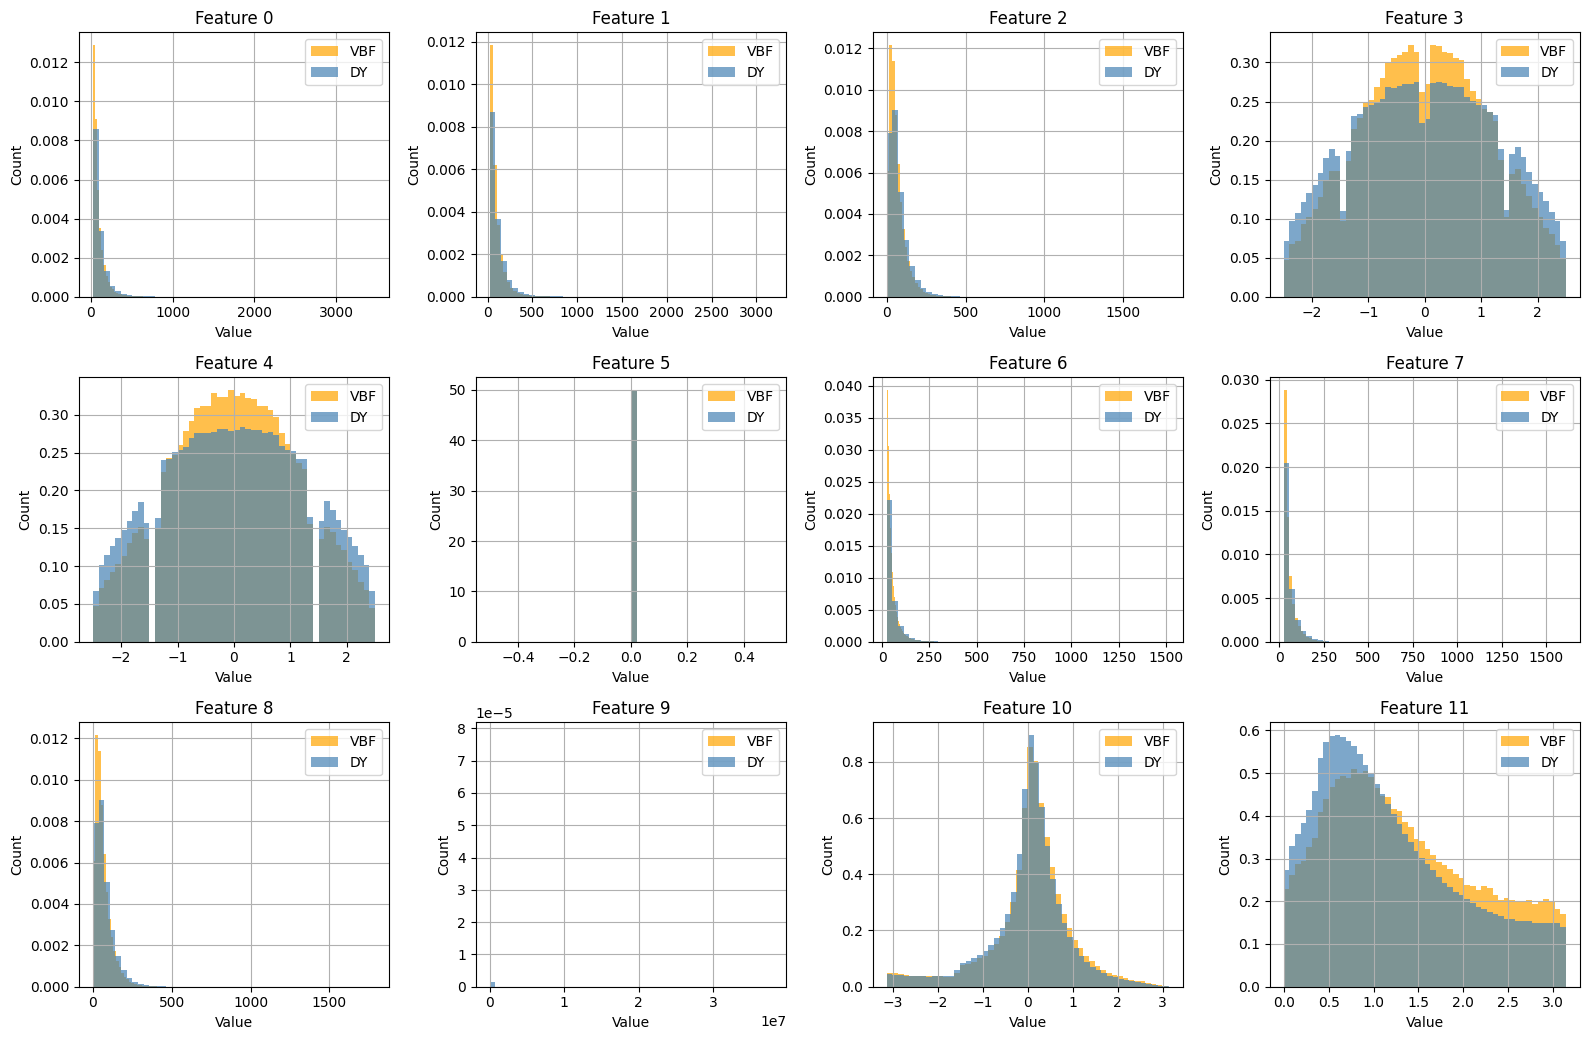

In [58]:
import matplotlib.pyplot as plt
import torch

# Ensure it's a numpy array for easier plotting

n_features = vbf_input_data.shape[1]
n_cols = 4  # number of plots per row
n_rows = (n_features + n_cols - 1) // n_cols

plt.figure(figsize=(4 * n_cols, 3.5 * n_rows))

for i in range(n_features):
    plt.subplot(n_rows, n_cols, i + 1)

    plt.hist(vbf_input_data[:, i], bins=50, color='orange', alpha=0.7, density=True, label='VBF')
    plt.hist(dy_input_data[:, i], bins=50, color='steelblue', alpha=0.7, density=True, label='DY')
    
    plt.title(f'Feature {i}')
    plt.xlabel('Value')
    plt.ylabel('Count')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()


In [59]:
DNNScaler = ColumnTransformer(
    [('E', LogMinMaxScaler(), [0, 1, 2]),
    ('eta', StandardScaler(), [3, 4, 5]),
    ('pt',LogMinMaxScaler(), [6, 7, 8]),
    ('opening_angle', MinMaxScaler(), [11]),
    ('lep_met_angle_signed', StandardScaler(), [10]),
    ('mz_reco', LogMinMaxScaler(), [9]),
    ],
)


# 1. Target for evaluation
true_targets = dy_metadata[:, MetadataIndex.MZ_TRUTH.value]

# 2. Apply DNNScaler
# Make sure your input is a NumPy array of shape (n_samples, 12)
X_scaled = DNNScaler.fit_transform(dy_input_data)

VBF_scaled = DNNScaler.fit_transform(vbf_input_data)

# 3. Convert to torch tensor
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
VBF_tensor = torch.tensor(VBF_scaled, dtype=torch.float32)

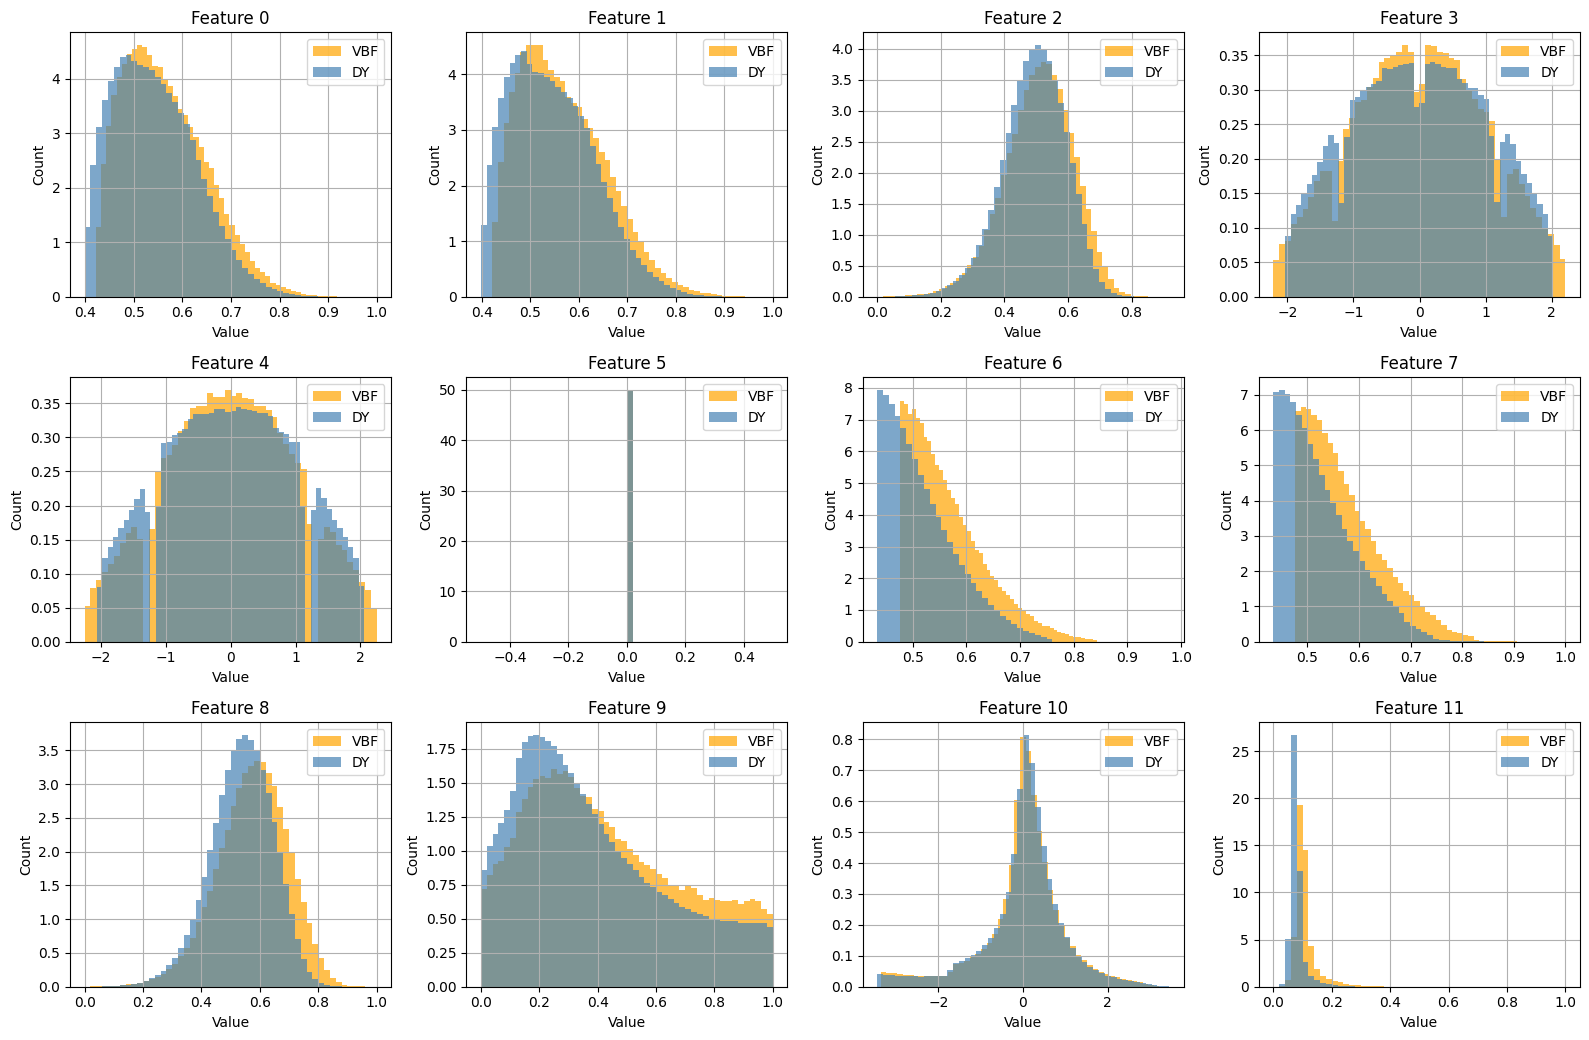

In [60]:
import matplotlib.pyplot as plt
import torch

# Ensure it's a numpy array for easier plotting
X_np = X_tensor.numpy()
VBF_np = VBF_tensor.numpy()

n_features = X_np.shape[1]
n_cols = 4  # number of plots per row
n_rows = (n_features + n_cols - 1) // n_cols

plt.figure(figsize=(4 * n_cols, 3.5 * n_rows))

for i in range(n_features):
    plt.subplot(n_rows, n_cols, i + 1)

    plt.hist(VBF_np[:, i], bins=50, color='orange', alpha=0.7, density=True, label='VBF')
    plt.hist(X_np[:, i], bins=50, color='steelblue', alpha=0.7, density=True, label='DY')
    plt.title(f'Feature {i}')
    plt.xlabel('Value')
    plt.ylabel('Count')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()


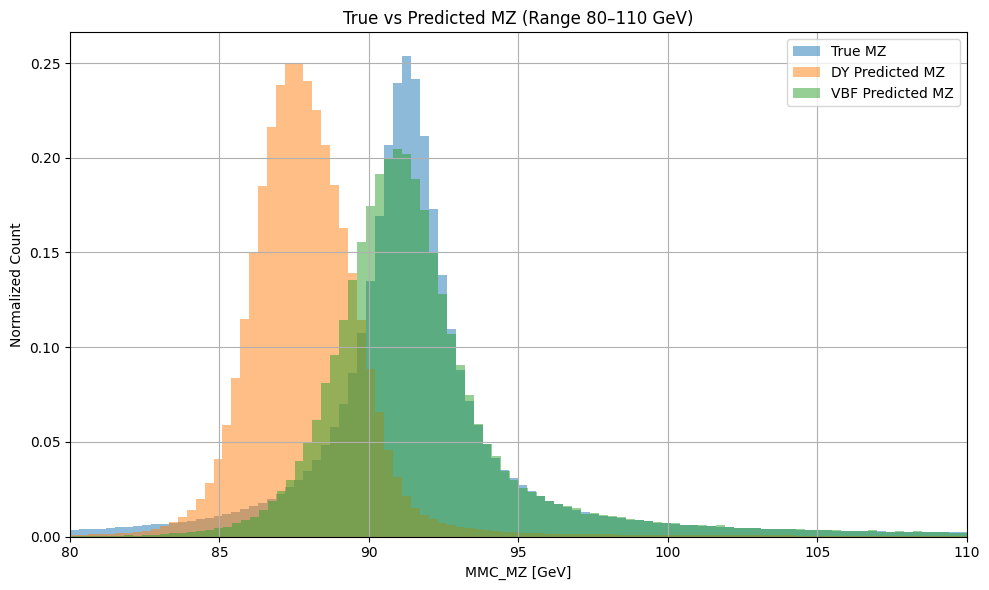

In [61]:

# 4. Run predictions
with torch.no_grad():
    dy_predictions = model(X_tensor).squeeze().cpu().numpy()  # shape: (n_samples,)
    vbf_predictions = model(VBF_tensor).squeeze().cpu().numpy()  # shape: (n_samples,)

import matplotlib.pyplot as plt
import numpy as np

# Define desired range
mz_min, mz_max = 80, 110

# Filter values to be within [80, 110]
true_filtered = true_targets[(true_targets >= mz_min) & (true_targets <= mz_max)]
dy_pred_filtered = dy_predictions[(dy_predictions >= mz_min) & (dy_predictions <= mz_max)]
vbf_pred_filtered = vbf_predictions[(vbf_predictions >= mz_min) & (vbf_predictions <= mz_max)]

# Plot
plt.figure(figsize=(10, 6))
plt.hist(true_filtered, bins=100, alpha=0.5, label='True MZ', density=True)
plt.hist(dy_pred_filtered, bins=100, alpha=0.5, label='DY Predicted MZ', density=True)
plt.hist(vbf_pred_filtered, bins=100, alpha=0.5, label='VBF Predicted MZ', density=True)

plt.xlabel("MMC_MZ [GeV]")
plt.ylabel("Normalized Count")
plt.title("True vs Predicted MZ (Range 80–110 GeV)")
plt.legend()
plt.grid(True)
plt.xlim(mz_min, mz_max)
plt.tight_layout()
plt.show()

In [62]:
import torch
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
import torch.nn.functional as F
import torch.optim as optim

# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# First split: train + val vs test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_tensor, true_targets, test_size=0.2, random_state=42)

# Second split: train vs val
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, random_state=42)

batch_size = 8192  # you can adjust this

# Create DataLoaders
train_loader = DataLoader(TensorDataset(X_train, torch.tensor(y_train, dtype=torch.float32)), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, torch.tensor(y_val, dtype=torch.float32)), batch_size=batch_size)
test_loader = DataLoader(TensorDataset(X_test, torch.tensor(y_test, dtype=torch.float32)), batch_size=batch_size)

# Move model to device
model = model.to(device)

criterion = nn.SmoothL1Loss(reduction='mean', beta=10.0)
optimizer = optim.AdamW(model.parameters(), lr=1e-3)

n_epochs = 5
train_losses = []
val_losses = []

for epoch in range(n_epochs):
    epoch_train_loss = 0
    model.train()
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        optimizer.zero_grad()
        preds = model(batch_X).squeeze()
        loss = criterion(preds, batch_y)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item()

    epoch_train_loss /= len(train_loader)
    train_losses.append(epoch_train_loss)

    model.eval()
    with torch.no_grad():
        val_loss = 0
        for val_X, val_y in val_loader:
            val_X, val_y = val_X.to(device), val_y.to(device)
            val_preds = model(val_X).squeeze()
            val_loss += criterion(val_preds, val_y).item()
        val_loss /= len(val_loader)
        val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{n_epochs} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {val_loss:.4f}", end='\r')


Using device: cuda
Epoch 5/5 | Train Loss: 4.9847 | Val Loss: 4.2635

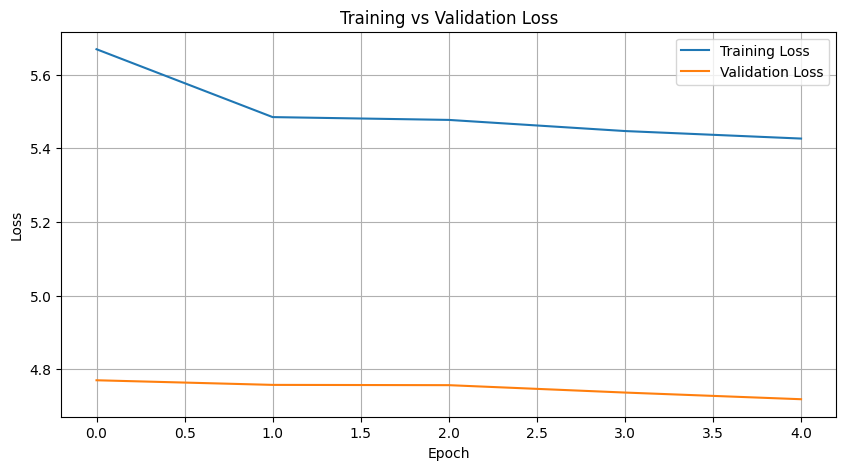

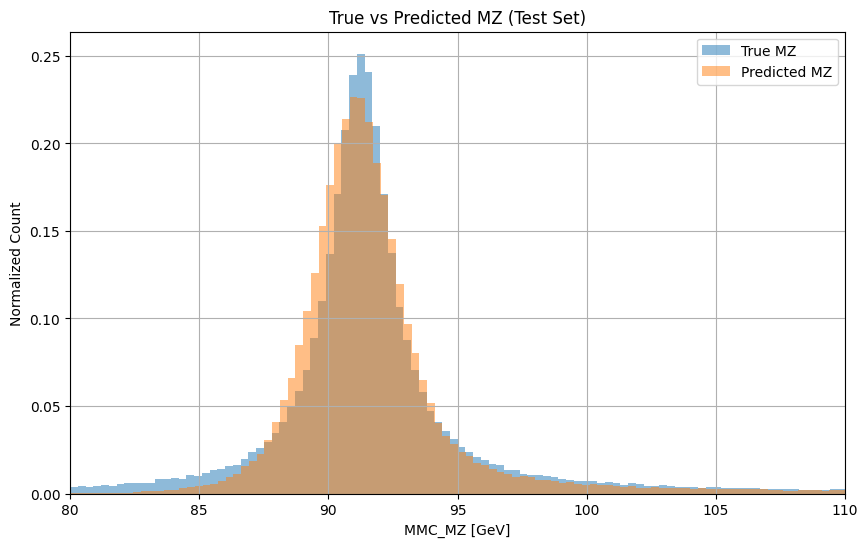

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# Switch model to eval mode
model.eval()

# Run on test set
all_preds = []
all_targets = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        preds = model(batch_X).squeeze().cpu().numpy()
        targets = batch_y.numpy()
        all_preds.extend(preds)
        all_targets.extend(targets)

# Convert to NumPy arrays
import numpy as np
all_preds = np.array(all_preds)
all_targets = np.array(all_targets)

# Mask to select values in [80, 110]
pred_mask = (all_preds >= 80) & (all_preds <= 110)
target_mask = (all_targets >= 80) & (all_targets <= 110)

filtered_targets = all_targets[target_mask]
filtered_preds = all_preds[pred_mask]

# Plot
plt.figure(figsize=(10, 6))
plt.hist(filtered_targets, bins=100, alpha=0.5, label='True MZ', density=True)
plt.hist(filtered_preds, bins=100, alpha=0.5, label='Predicted MZ', density=True)

plt.xlabel("MMC_MZ [GeV]")
plt.ylabel("Normalized Count")
plt.title("True vs Predicted MZ (Test Set)")
plt.legend()
plt.grid(True)
plt.xlim(80, 110)
plt.show()
